## Interkulturelle Vergleichsanalyse mit der World Values Survey (WVS)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
# Daten einlesen
df = pd.read_csv("../data/WVS_Cross-National_Wave_7_csv_v6_0.csv", sep = ",")

/var/folders/v6/9c6hcq397n90s3n8znn3v7vh0000gn/T/ipykernel_86288/1619012253.py:2: DtypeWarning: Columns (0: X002_02B, 1: V002A_01, 2: V001A_01, 3: Partyname, 4: Partyabb, 5: CPARTY, 6: CPARTYABB) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/WVS_Cross-National_Wave_7_csv_v6_0.csv", sep = ",")


In [4]:
df.head()

,version,doi,A_WAVE,A_YEAR,A_STUDY,B_COUNTRY,B_COUNTRY_ALPHA,C_COW_NUM,C_COW_ALPHA,D_INTERVIEW,...,WVS_Polmistrust_PartyVoter,WVS_LR_MedianVoter,WVS_LibCon_MedianVoter,v2psbars,v2psorgs,v2psprbrch,v2psprlnks,v2psplats,v2xnp_client,v2xps_party
0,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,20,AND,232,AND,20070001,...,62.434211,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
1,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,20,AND,232,AND,20070002,...,62.434211,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
2,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,20,AND,232,AND,20070003,...,62.434211,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
3,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,20,AND,232,AND,20070004,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,20,AND,232,AND,20070005,...,66.964286,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0


## Auswahl von Ländern und Merkmalen
- Nigeria: 566
- Phillipinen: 608
- Mexiko: 484
- Deutschland: 276
- Indien: 356

In [31]:
laender = [566, 608, 484, 276, 356]
df_country = df[df["B_COUNTRY"].isin(laender)]
df_country.head()

,version,doi,A_WAVE,A_YEAR,A_STUDY,B_COUNTRY,B_COUNTRY_ALPHA,C_COW_NUM,C_COW_ALPHA,D_INTERVIEW,...,WVS_Polmistrust_PartyVoter,WVS_LR_MedianVoter,WVS_LibCon_MedianVoter,v2psbars,v2psorgs,v2psprbrch,v2psprlnks,v2psplats,v2xnp_client,v2xps_party
21846,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,276,DEU,255,GMY,276070001,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21847,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,276,DEU,255,GMY,276070002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21848,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,276,DEU,255,GMY,276070003,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21849,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,276,DEU,255,GMY,276070004,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21850,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,276,DEU,255,GMY,276070005,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
df_country["B_COUNTRY_ALPHA"].value_counts()

B_COUNTRY_ALPHA
MEX    1741
IND    1692
DEU    1528
NGA    1237
PHL    1200
Name: count, dtype: int64

## Merkmale zu Indikatoren zusammenfassen

In [33]:
fragen = ['Q32', 'Q33', 'Q28', 'Q235', 'Q71', 'Q43', 'Q150', 'Q48', 'Q149']


# Nur relevante Spalten + Ländervariable behalten
df_merkm = df_country[["B_COUNTRY_ALPHA"] + fragen].copy()

In [34]:
# ── Indikator 1: Arbeit und Kinder ──
df_merkm['idx_arbeit'] = df[['Q32', 'Q33', 'Q28']].mean(axis=1).copy()

# ── Indikator 2: Autoritärer Führungsstil ──
df_merkm['idx_fuehrung'] = df[['Q235', 'Q71']].mean(axis=1).copy()

# ── Indikator 3: Freiheit und Sicherheit ──
df_merkm['idx_freiheit'] = df[['Q43', 'Q150', 'Q48', 'Q149']].mean(axis=1).copy()

indizes = ['idx_arbeit', 'idx_fuehrung', 'idx_freiheit']

In [35]:
df_merkm.head()

,B_COUNTRY_ALPHA,Q32,Q33,Q28,Q235,Q71,Q43,Q150,Q48,Q149,idx_arbeit,idx_fuehrung,idx_freiheit
21846,DEU,1,5,1,3,2,1,1,8,2,2.333333,2.5,3.00
21847,DEU,2,4,3,1,2,1,1,8,-1,3.000000,1.5,2.25
21848,DEU,1,3,-1,4,3,2,2,5,1,1.000000,3.5,2.50
21849,DEU,3,5,4,4,2,2,1,8,1,4.000000,3.0,3.00
21850,DEU,2,4,4,2,3,3,2,9,2,3.333333,2.5,4.00


In [36]:
df_idx = df_merkm[["B_COUNTRY_ALPHA"] + indizes].copy()
df_idx.head()

,B_COUNTRY_ALPHA,idx_arbeit,idx_fuehrung,idx_freiheit
21846,DEU,2.333333,2.5,3.00
21847,DEU,3.000000,1.5,2.25
21848,DEU,1.000000,3.5,2.50
21849,DEU,4.000000,3.0,3.00
21850,DEU,3.333333,2.5,4.00


In [37]:
# Mittelwerte pro Land berechnen
grouped = df_idx.groupby('B_COUNTRY_ALPHA')[['idx_arbeit', 'idx_fuehrung', 'idx_freiheit']].mean().round(1)

# Spaltennamen umbenennen
grouped.columns = ['Arbeit', 'Führung', 'Freiheit']

# Index (Ländernamen) anpassen
grouped.index.name = 'Land'

# LaTeX Tabelle ausgeben
latex_table = grouped.to_latex(
    caption='Mittelwerte der drei Indikatoren im Ländervergleich (WVS Wave 7, 2017–2022)',
    label='tab:indikatoren',
    position='h',
    column_format='lrrr',
    bold_rows=False
)

print(latex_table)

\begin{table}[h]
\caption{Mittelwerte der drei Indikatoren im Ländervergleich (WVS Wave 7, 2017–2022)}
\label{tab:indikatoren}
\begin{tabular}{lrrr}
\toprule
 & Arbeit & Autoritäre Disposition & Freiheit und Sicherheit \\
Land &  &  &  \\
\midrule
DEU & 3.000000 & 2.700000 & 2.900000 \\
IND & 2.200000 & 1.900000 & 3.100000 \\
MEX & 2.600000 & 2.700000 & 3.300000 \\
NGA & 2.600000 & 2.500000 & 2.900000 \\
PHL & 2.200000 & 2.000000 & 2.900000 \\
\bottomrule
\end{tabular}
\end{table}



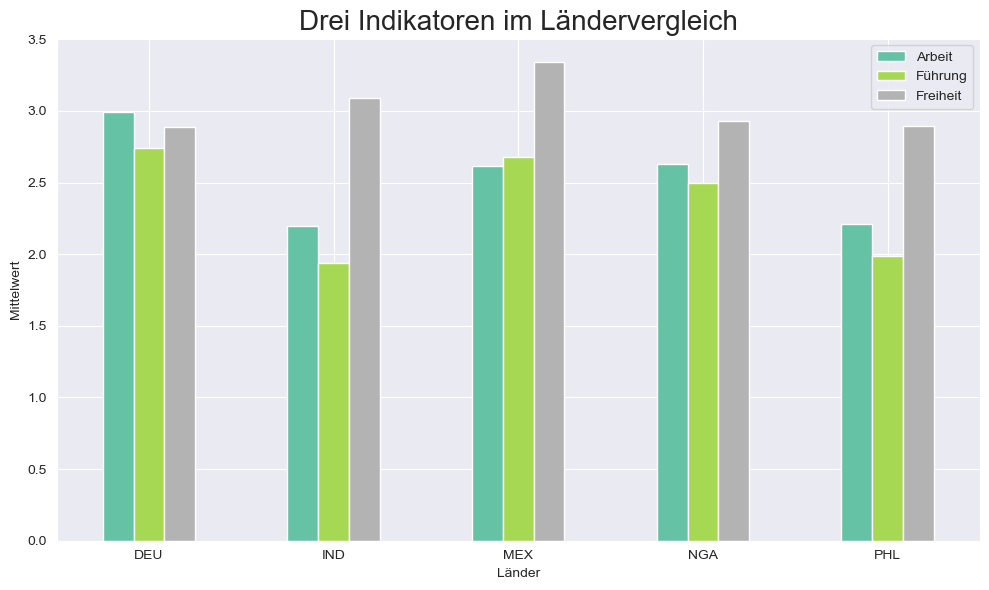

In [39]:
# Mittelwerte pro Land
grouped = df_idx.groupby('B_COUNTRY_ALPHA')[['idx_arbeit', 'idx_fuehrung', 'idx_freiheit']].mean()

grouped.plot(kind='bar', figsize=(10, 6), colormap='Set2')
plt.title('Drei Indikatoren im Ländervergleich', fontsize=20)
plt.ylabel('Mittelwert')
plt.xlabel('Länder')
plt.xticks(rotation=0)
plt.legend(['Arbeit', 'Führung', 'Freiheit'])
plt.tight_layout()
plt.savefig("indikatoren_vergleich.png", dpi=300)
plt.show()

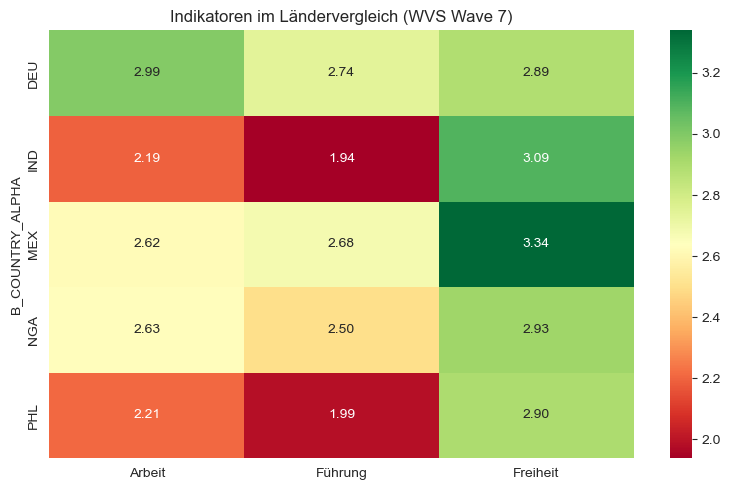

In [40]:
grouped = df_idx.groupby('B_COUNTRY_ALPHA')[['idx_arbeit', 'idx_fuehrung', 'idx_freiheit']].mean()

plt.figure(figsize=(8, 5))
sns.heatmap(grouped, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=['Arbeit', 'Führung', 'Freiheit'])
plt.title('Indikatoren im Ländervergleich (WVS Wave 7)')
plt.tight_layout()
plt.savefig("indikatoren_vergleich_heatmap.png", dpi=300)
plt.show()

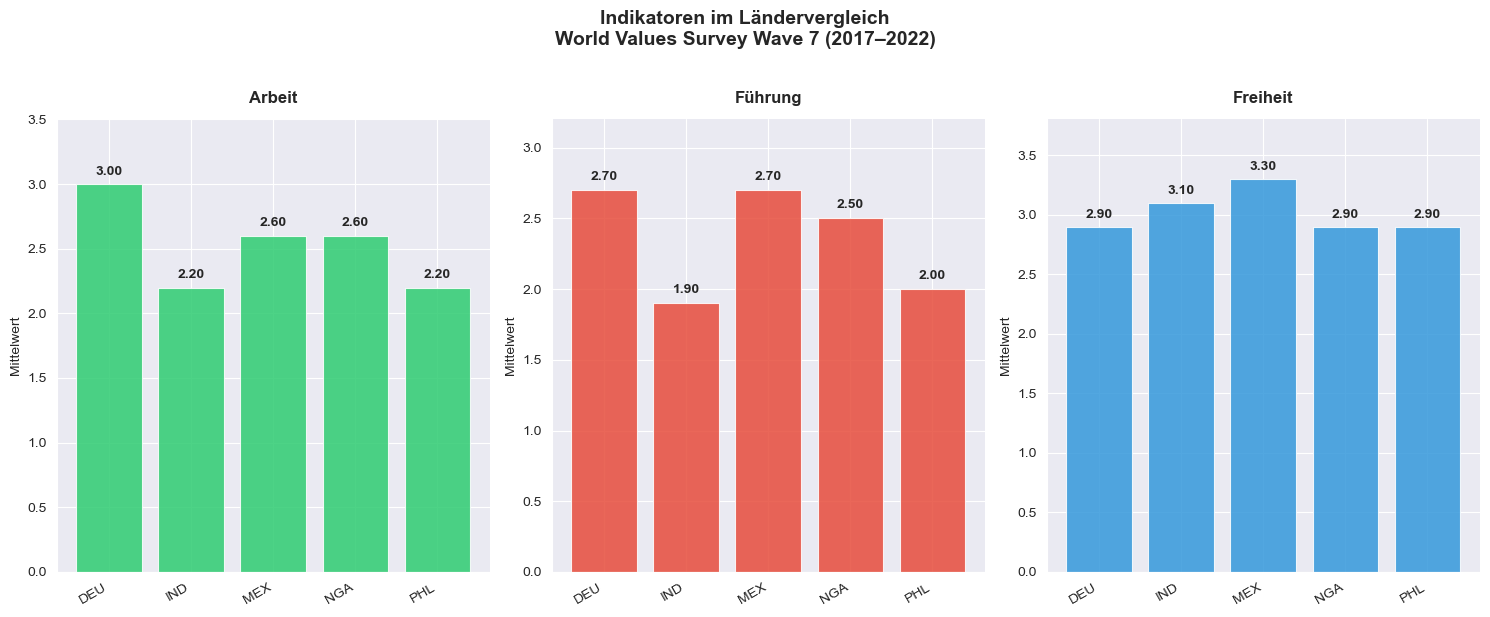

In [41]:
# Mittelwerte pro Land
grouped = df_idx.groupby('B_COUNTRY_ALPHA')[['idx_arbeit', 'idx_fuehrung', 'idx_freiheit']].mean().round(1)

# Länder und Indikatoren
länder = grouped.index.tolist()
indikatoren = {
    'Arbeit': grouped['idx_arbeit'],
    'Führung':     grouped['idx_fuehrung'],
    'Freiheit':            grouped['idx_freiheit']
}

farben = ['#2ecc71', '#e74c3c', '#3498db']

fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=False)

for ax, (titel, werte), farbe in zip(axes, indikatoren.items(), farben):
    bars = ax.bar(länder, werte, color=farbe, alpha=0.85, edgecolor='white', linewidth=0.8)

    # Werte über den Balken
    for bar, val in zip(bars, werte):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.05,
                f'{val:.2f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_title(titel, fontsize=12, fontweight='bold', pad=12)
    ax.set_ylabel('Mittelwert', fontsize=10)
    ax.set_xticks(range(len(länder)))
    ax.set_xticklabels(länder, rotation=30, ha='right', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(0, werte.max() + 0.5)

fig.suptitle('Indikatoren im Ländervergleich\nWorld Values Survey Wave 7 (2017–2022)',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('indikatoren_balken.png', dpi=300, bbox_inches='tight')
plt.show()

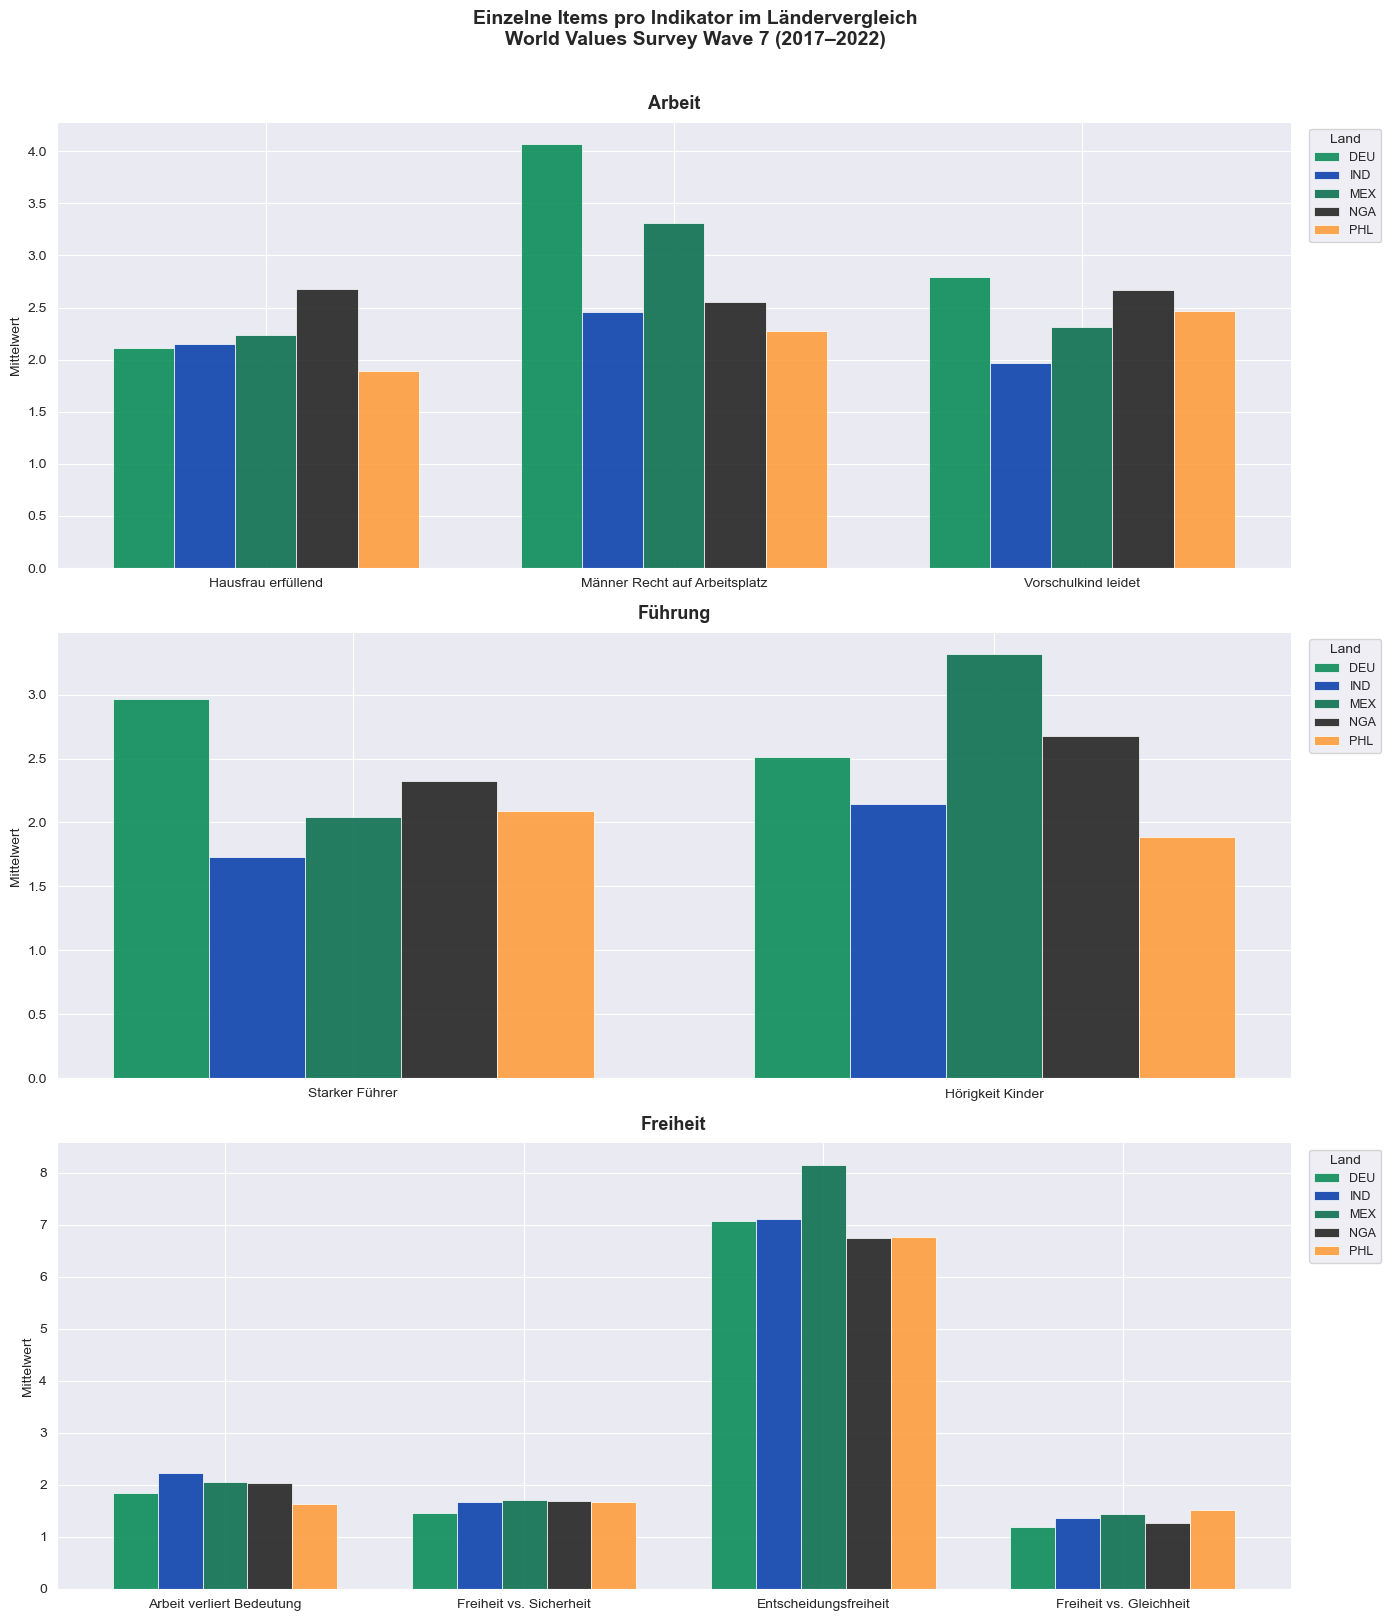

In [43]:
# ── Einzelne Items pro Indikator ──
items = {
    'Arbeit': ['Q32', 'Q33', 'Q28'],
    'Führung':     ['Q235', 'Q71'],
    'Freiheit':            ['Q43', 'Q150', 'Q48', 'Q149']
}
df_merkm['idx_arbeit'] = df[['Q32', 'Q33', 'Q28']].mean(axis=1).copy()

# ── Indikator 2: Autoritärer Führungsstil ──
df_merkm['idx_fuehrung'] = df[['Q235', 'Q71']].mean(axis=1).copy()

# ── Indikator 3: Freiheit und Sicherheit ──
df_merkm['idx_freiheit'] = df[['Q43', 'Q150', 'Q48', 'Q149']].mean(axis=1).copy()


item_labels = {
    'Q32': 'Hausfrau erfüllend',
    'Q33': 'Männer Recht auf Arbeitsplatz',
    'Q28': 'Vorschulkind leidet',
    'Q235': 'Starker Führer',
    'Q71': 'Hörigkeit Kinder',
    'Q43': 'Arbeit verliert Bedeutung',
    'Q150': 'Freiheit vs. Sicherheit',
    'Q48': 'Entscheidungsfreiheit',
    'Q149': 'Freiheit vs. Gleichheit'
}

länder = df_merkm['B_COUNTRY_ALPHA'].unique()
farben = ['#008751', '#0038A8', '#006847', '#1a1a1a', '#FF9933']
land_farben = dict(zip(länder, farben))

fig, axes = plt.subplots(3, 1, figsize=(14, 16))

for ax, (indikator, item_list) in zip(axes, items.items()):

    # Mittelwerte pro Land und Item
    means = df_merkm.groupby('B_COUNTRY_ALPHA')[item_list].mean()

    x = np.arange(len(item_list))
    n = len(länder)
    width = 0.15
    offsets = np.linspace(-(n-1)/2 * width, (n-1)/2 * width, n)

    for land, offset, farbe in zip(länder, offsets, farben):
        werte = means.loc[land, item_list].values
        bars = ax.bar(x + offset, werte, width=width,
                      label=land, color=farbe, alpha=0.85,
                      edgecolor='white', linewidth=0.6)

    ax.set_title(indikator, fontsize=13, fontweight='bold', pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels([item_labels[i] for i in item_list], fontsize=10)
    ax.set_ylabel('Mittelwert', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(title='Land', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

fig.suptitle('Einzelne Items pro Indikator im Ländervergleich\nWorld Values Survey Wave 7 (2017–2022)',
             fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('items_pro_indikator.png', dpi=300, bbox_inches='tight')
plt.show()

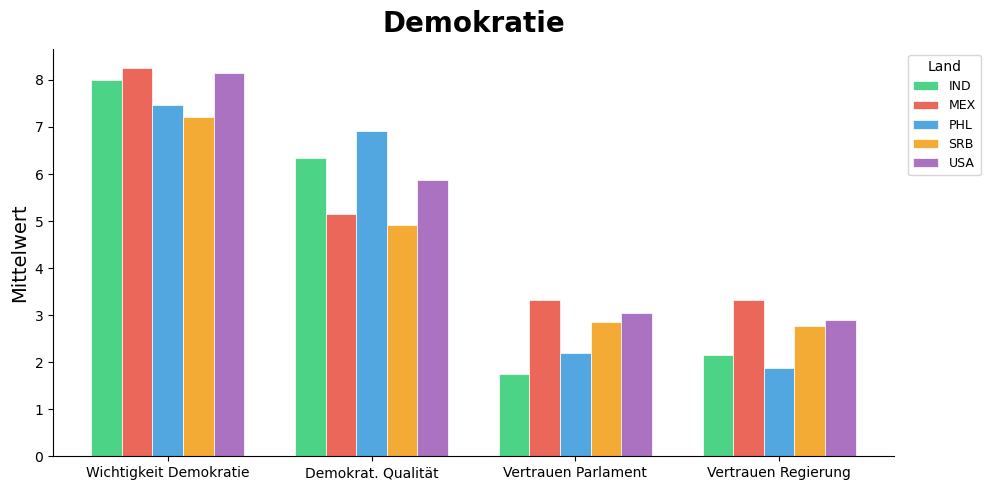

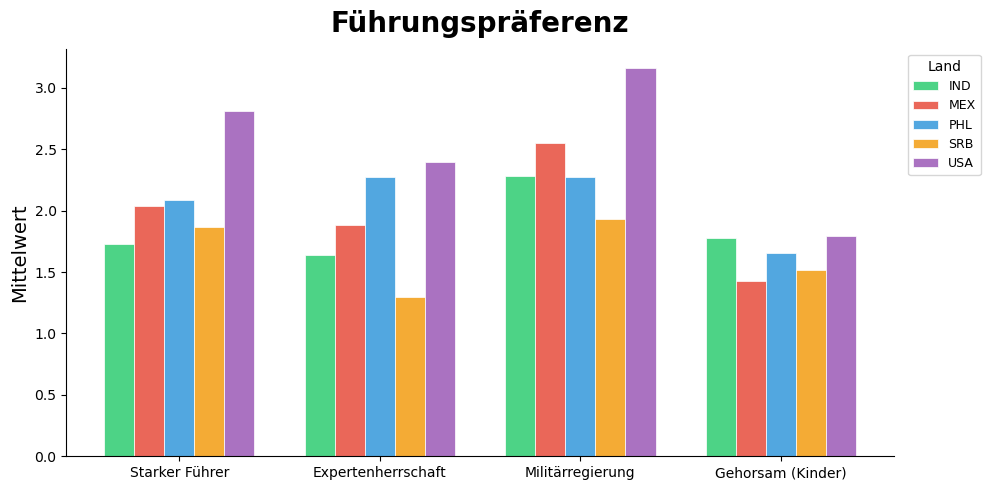

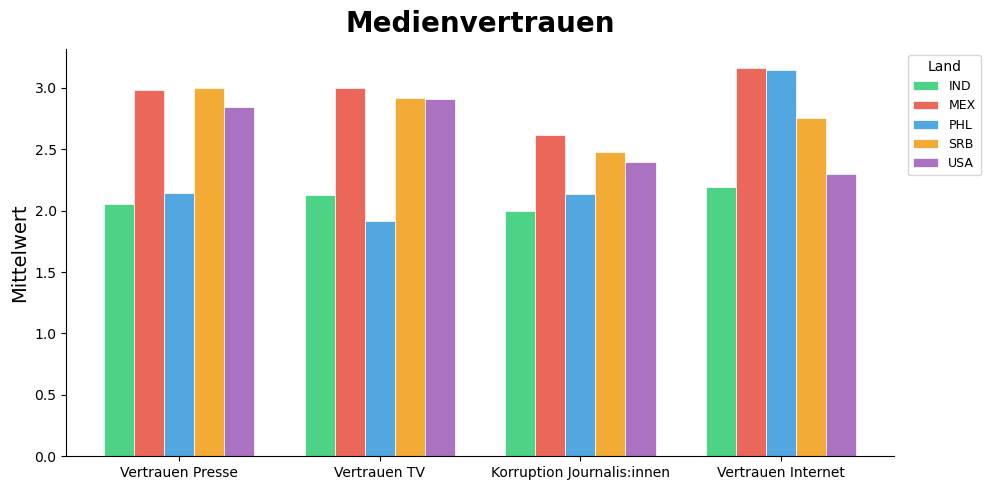

In [142]:
# ── Einzelne Items pro Indikator ──
items = {
    'Demokratie': ['Q250', 'Q251', 'Q73', 'Q71'],
    'Führungspräferenz':     ['Q235', 'Q236', 'Q237', 'Q17'],
    'Medienvertrauen':            ['Q66', 'Q67', 'Q117', 'Q207']
}

item_labels = {
    'Q250': 'Wichtigkeit Demokratie',
    'Q251': 'Demokrat. Qualität',
    'Q73': 'Vertrauen Parlament',
    'Q71': 'Vertrauen Regierung',
    'Q235': 'Starker Führer',
    'Q236': 'Expertenherrschaft',
    'Q237': 'Militärregierung',
    'Q17':  'Gehorsam (Kinder)',
    'Q66': 'Vertrauen Presse',
    'Q67': 'Vertrauen TV',
    'Q117': 'Korruption Journalis:innen',
    'Q207': 'Vertrauen Internet'
}

länder = df_merkm['B_COUNTRY_ALPHA'].unique()
farben = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6']

for indikator, item_list in items.items():

    fig, ax = plt.subplots(figsize=(10, 5))

    means = df_merkm.groupby('B_COUNTRY_ALPHA')[item_list].mean()

    x = np.arange(len(item_list))
    n = len(länder)
    width = 0.15
    offsets = np.linspace(-(n-1)/2 * width, (n-1)/2 * width, n)

    for land, offset, farbe in zip(länder, offsets, farben):
        werte = means.loc[land, item_list].values
        ax.bar(x + offset, werte, width=width,
               label=land, color=farbe, alpha=0.85,
               edgecolor='white', linewidth=0.6)

    ax.set_title(indikator, fontsize=20, fontweight='bold', pad=12)
    ax.set_xticks(x)
    ax.set_xticklabels([item_labels[i] for i in item_list], fontsize=10)
    ax.set_ylabel('Mittelwert', fontsize=14)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(title='Land', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

    plt.tight_layout()

    dateiname = f"items_{indikator.replace(' ', '_').replace('&', 'und')}.png"
    plt.savefig(dateiname, dpi=300, bbox_inches='tight')
    plt.show()